# Epoch Bütçesi Deneyi

Bu notebook, LSTM ve GRU modelleri için 50 ve 100 epoch bütçelerini validation döneminde karşılaştırır. Yalnızca epoch üst sınırı değiştirilir; veri, lookback, mimari, optimizer ve seed sabit tutulur. Her model kendi seed'i sıfırlanmış DataLoader'ı ile eğitilir. Test dönemi kullanılmaz.

In [1]:
import copy
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from torch import nn
from torch.optim import Adam

from ms_stock_prediction.models import GRUModel, LSTMModel, count_trainable_parameters
from ms_stock_prediction.preprocessing import (
    PreparationConfig,
    load_close_prices,
    prepare_time_series,
)
from ms_stock_prediction.training import evaluate_loss, train_one_epoch

SEED = 42
EPOCH_BUDGETS = (50, 100)
LEARNING_RATE = 0.001
HIDDEN_SIZE = 32
NUM_LAYERS = 2
BATCH_SIZE = 32
LOOKBACK = 20
DEVICE = torch.device("cpu")

pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.style.use("seaborn-v0_8-whitegrid")

## Kontrollü deney düzeni

Her model 100 epoch boyunca bir kez eğitilir. 50. ve 100. epoch sınırlarında, o ana kadar görülen en düşük validation kaybına sahip ağırlıklar ayrı ayrı saklanır. Böylece ek 50 epoch'un etkisi aynı eğitim yörüngesi üzerinde ölçülür.

In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "pyproject.toml").exists():
    raise FileNotFoundError("Proje kökü bulunamadı. Notebook'u proje içinde çalıştırın.")

DATA_PATH = PROJECT_ROOT / "data/raw/msft_daily_latest.csv"
prices = load_close_prices(DATA_PATH)
config = PreparationConfig(
    lookback=LOOKBACK,
    batch_size=BATCH_SIZE,
    shuffle_seed=SEED,
)

print(f"Kapanış fiyatı gözlemi: {len(prices):,}")
print(f"Tarih aralığı: {prices.index.min().date()} - {prices.index.max().date()}")

Kapanış fiyatı gözlemi: 4,156
Tarih aralığı: 2010-01-04 - 2026-07-14


In [3]:
def regression_metrics(actual, predicted):
    errors = predicted - actual
    mse = float(np.mean(errors**2))
    return {
        "MSE (USD²)": mse,
        "RMSE (USD)": float(np.sqrt(mse)),
        "MAE (USD)": float(np.mean(np.abs(errors))),
    }


def run_epoch_budget_experiment(model_class, model_name):
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    prepared = prepare_time_series(prices, config)
    model = model_class(
        input_size=1,
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        output_size=1,
    ).to(DEVICE)
    loss_function = nn.MSELoss()
    optimizer = Adam(model.parameters(), lr=LEARNING_RATE)

    history = []
    checkpoints = {}
    best_validation_loss = float("inf")
    best_epoch = 0
    best_model_state = None
    training_started = time.perf_counter()

    for epoch in range(1, max(EPOCH_BUDGETS) + 1):
        train_loss = train_one_epoch(
            model, prepared.train_loader, optimizer, loss_function, DEVICE
        )
        validation_loss = evaluate_loss(
            model, prepared.validation_loader, loss_function, DEVICE
        )
        history.append(
            {
                "Epoch": epoch,
                "Train MSE (scaled)": train_loss,
                "Validation MSE (scaled)": validation_loss,
            }
        )

        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            best_epoch = epoch
            best_model_state = copy.deepcopy(model.state_dict())

        if epoch in EPOCH_BUDGETS:
            checkpoints[epoch] = {
                "state": copy.deepcopy(best_model_state),
                "selected_epoch": best_epoch,
                "validation_loss": best_validation_loss,
                "training_seconds": time.perf_counter() - training_started,
            }

        if epoch == 1 or epoch % 10 == 0:
            print(
                f"{model_name} | epoch {epoch:03d}/{max(EPOCH_BUDGETS)} | "
                f"train={train_loss:.6f} | validation={validation_loss:.6f}"
            )

    if set(checkpoints) != set(EPOCH_BUDGETS):
        raise RuntimeError("Epoch bütçelerine ait model ağırlıkları eksik.")

    actual_scaled = prepared.y_validation.numpy()
    actual_usd = prepared.scaler.inverse_transform(actual_scaled).ravel()
    outcomes = []
    predictions = {}

    for budget in EPOCH_BUDGETS:
        checkpoint = checkpoints[budget]
        model.load_state_dict(checkpoint["state"])
        model.eval()
        with torch.no_grad():
            predicted_scaled = model(prepared.X_validation.to(DEVICE)).cpu().numpy()
        predicted_usd = prepared.scaler.inverse_transform(predicted_scaled).ravel()
        metrics = regression_metrics(actual_usd, predicted_usd)
        outcomes.append(
            {
                "Model": model_name,
                "Epoch bütçesi": budget,
                "Seçilen epoch": checkpoint["selected_epoch"],
                **metrics,
                "Parametre": count_trainable_parameters(model),
                "Eğitim süresi (sn)": checkpoint["training_seconds"],
            }
        )
        predictions[budget] = predicted_usd

    return (
        prepared,
        pd.DataFrame(history).set_index("Epoch"),
        outcomes,
        predictions,
        actual_usd,
    )

## Eğitim çalışmaları

LSTM ve GRU sırasıyla, birbirinden bağımsız fakat aynı seed ile hazırlanmış DataLoader'lar kullanır.

In [4]:
(
    prepared_lstm,
    lstm_history,
    lstm_outcomes,
    lstm_predictions,
    actual_usd,
) = run_epoch_budget_experiment(LSTMModel, "LSTM")

(
    prepared_gru,
    gru_history,
    gru_outcomes,
    gru_predictions,
    gru_actual_usd,
) = run_epoch_budget_experiment(GRUModel, "GRU")

assert np.array_equal(actual_usd, gru_actual_usd)
assert prepared_lstm.validation_target_dates.equals(
    prepared_gru.validation_target_dates
)

LSTM | epoch 001/100 | train=0.141562 | validation=0.336362


LSTM | epoch 010/100 | train=0.000513 | validation=0.020909


LSTM | epoch 020/100 | train=0.000420 | validation=0.006453


LSTM | epoch 030/100 | train=0.000328 | validation=0.004541


LSTM | epoch 040/100 | train=0.000311 | validation=0.006775


...

GRU | epoch 060/100 | train=0.000185 | validation=0.002871


GRU | epoch 070/100 | train=0.000185 | validation=0.002690


GRU | epoch 080/100 | train=0.000189 | validation=0.002280


GRU | epoch 090/100 | train=0.000196 | validation=0.002606


GRU | epoch 100/100 | train=0.000187 | validation=0.002792


In [5]:
naive_scaled = prepared_lstm.X_validation[:, -1, 0].numpy().reshape(-1, 1)
naive_usd = prepared_lstm.scaler.inverse_transform(naive_scaled).ravel()
naive_metrics = regression_metrics(actual_usd, naive_usd)

results = pd.DataFrame(lstm_outcomes + gru_outcomes)
results = results.sort_values(["Model", "Epoch bütçesi"]).reset_index(drop=True)
display(results)

print(
    f"Naive baseline | RMSE={naive_metrics['RMSE (USD)']:.4f} USD | "
    f"MAE={naive_metrics['MAE (USD)']:.4f} USD"
)

,Model,Epoch bütçesi,Seçilen epoch,MSE (USD²),RMSE (USD),MAE (USD),Parametre,Eğitim süresi (sn)
0,GRU,50,50,44.7492,6.6895,5.2316,9729,64.6038
1,GRU,100,72,37.4128,6.1166,4.8147,9729,129.6091
2,LSTM,50,49,47.0467,6.8591,5.4549,12961,20.4012
3,LSTM,100,96,29.4468,5.4265,4.2340,12961,41.3876


Naive baseline | RMSE=4.9875 USD | MAE=3.7967 USD


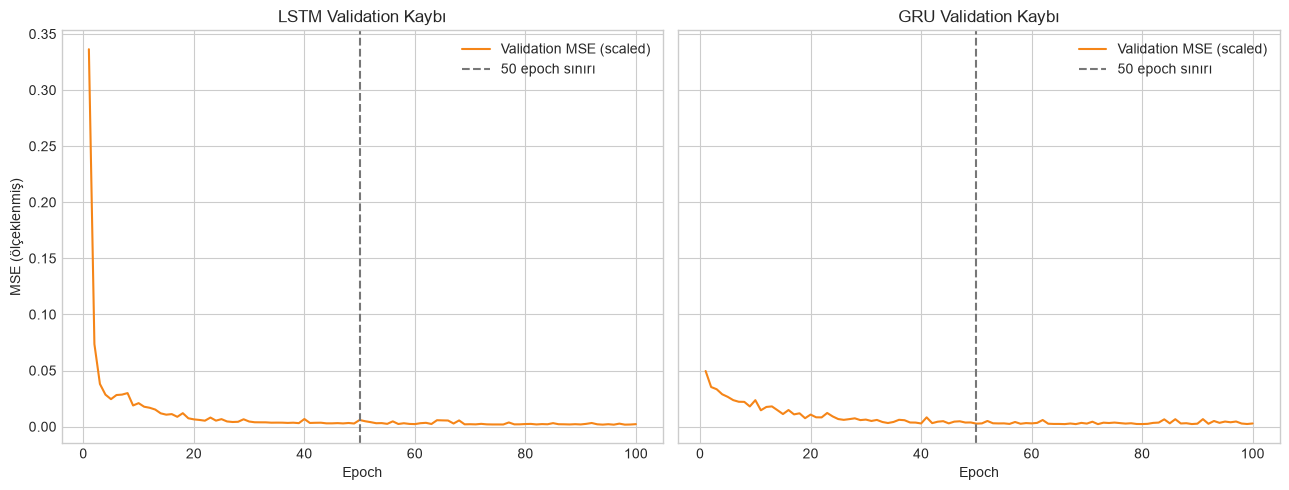

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, history, model_name in [
    (axes[0], lstm_history, "LSTM"),
    (axes[1], gru_history, "GRU"),
]:
    history["Validation MSE (scaled)"].plot(ax=ax, color="#F58518")
    ax.axvline(50, color="#777777", linestyle="--", label="50 epoch sınırı")
    ax.set_title(f"{model_name} Validation Kaybı")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE (ölçeklenmiş)")
    ax.legend()
plt.tight_layout()
plt.show()

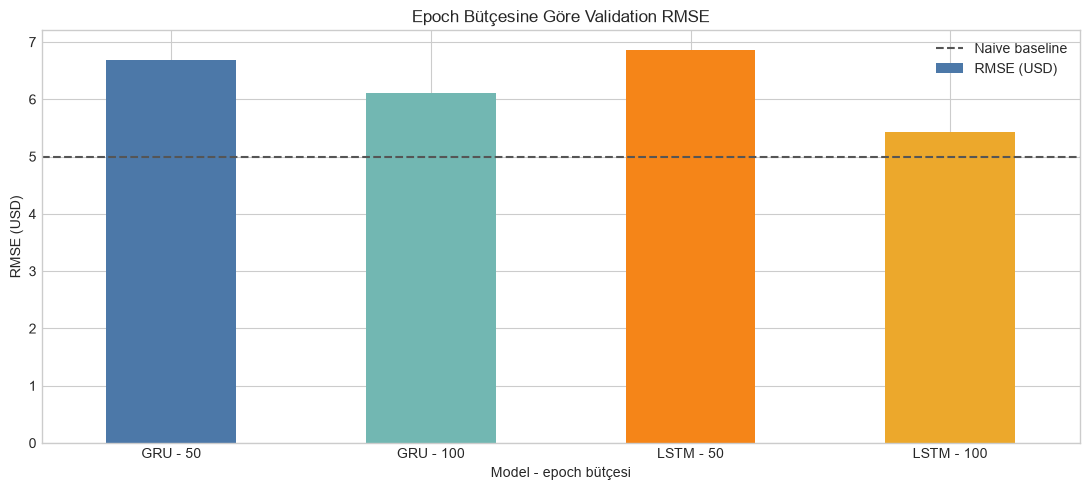

In [7]:
plot_results = results.copy()
plot_results["Deney"] = (
    plot_results["Model"] + " - " + plot_results["Epoch bütçesi"].astype(str)
)
ax = plot_results.set_index("Deney")["RMSE (USD)"].plot(
    kind="bar", figsize=(11, 5), rot=0, color=["#4C78A8", "#72B7B2", "#F58518", "#ECA82C"]
)
ax.axhline(
    naive_metrics["RMSE (USD)"],
    color="#555555",
    linestyle="--",
    label="Naive baseline",
)
ax.set_title("Epoch Bütçesine Göre Validation RMSE")
ax.set_xlabel("Model - epoch bütçesi")
ax.set_ylabel("RMSE (USD)")
ax.legend()
plt.tight_layout()
plt.show()

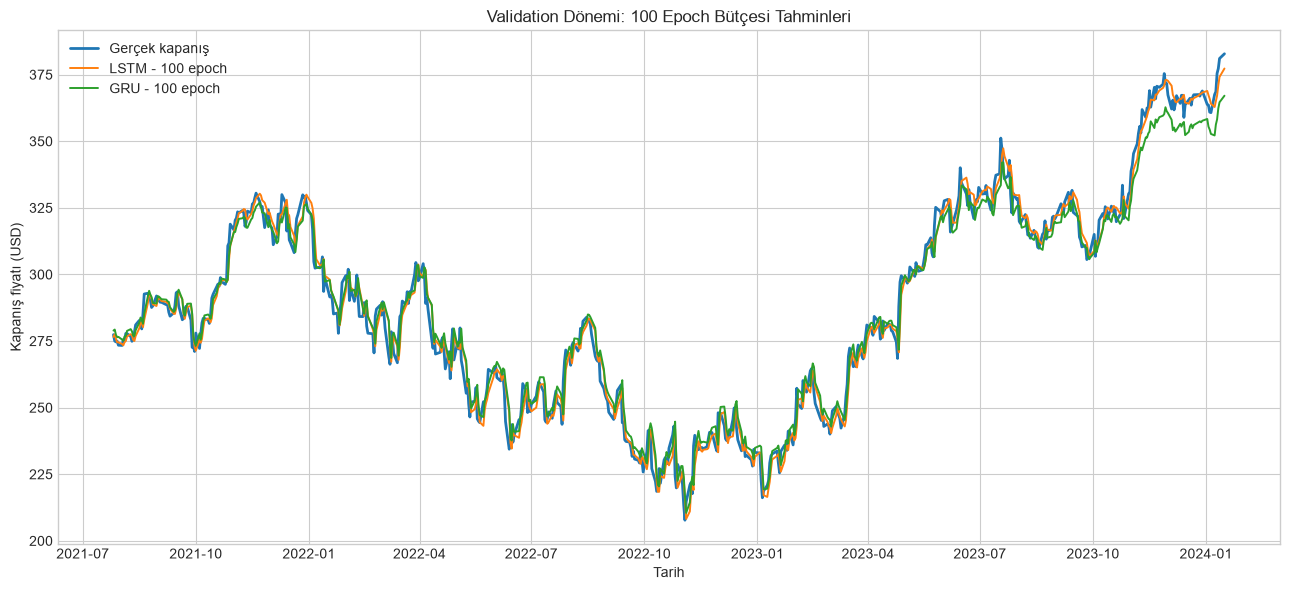

In [8]:
validation_dates = prepared_lstm.validation_target_dates
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(validation_dates, actual_usd, label="Gerçek kapanış", linewidth=2)
ax.plot(validation_dates, lstm_predictions[100], label="LSTM - 100 epoch", linewidth=1.4)
ax.plot(validation_dates, gru_predictions[100], label="GRU - 100 epoch", linewidth=1.4)
ax.set_title("Validation Dönemi: 100 Epoch Bütçesi Tahminleri")
ax.set_xlabel("Tarih")
ax.set_ylabel("Kapanış fiyatı (USD)")
ax.legend()
plt.tight_layout()
plt.show()

## Validation bulguları

Aşağıdaki özet epoch bütçesinin etkisini gösterir. Sonuçlar model seçimi için ayrılmış validation dönemine aittir; test performansı değildir.

In [9]:
for model_name in ["LSTM", "GRU"]:
    model_rows = results[results["Model"] == model_name].set_index("Epoch bütçesi")
    rmse_50 = model_rows.loc[50, "RMSE (USD)"]
    rmse_100 = model_rows.loc[100, "RMSE (USD)"]
    print(
        f"{model_name} | 50 epoch RMSE={rmse_50:.4f} | "
        f"100 epoch RMSE={rmse_100:.4f} | değişim={rmse_100 - rmse_50:+.4f} USD"
    )

best_index = results["RMSE (USD)"].idxmin()
best_row = results.loc[best_index]
assert np.isfinite(results[["RMSE (USD)", "MAE (USD)"]].to_numpy()).all()
assert validation_dates.max() < prepared_lstm.test_target_dates.min()

print(
    f"En düşük RNN validation RMSE: {best_row['Model']} / "
    f"{int(best_row['Epoch bütçesi'])} epoch bütçesi / "
    f"{best_row['RMSE (USD)']:.4f} USD"
)
print(f"Naive baseline validation RMSE: {naive_metrics['RMSE (USD)']:.4f} USD")
print("Test dönemine ait tahmin veya metrik hesaplanmadı.")

LSTM | 50 epoch RMSE=6.8591 | 100 epoch RMSE=5.4265 | değişim=-1.4326 USD
GRU | 50 epoch RMSE=6.6895 | 100 epoch RMSE=6.1166 | değişim=-0.5729 USD
En düşük RNN validation RMSE: LSTM / 100 epoch bütçesi / 5.4265 USD
Naive baseline validation RMSE: 4.9875 USD
Test dönemine ait tahmin veya metrik hesaplanmadı.
